### **Multi-Asset Time-Series Momentum Strategy with Transaction Costs and Benchmark Comparison**

### **Introduction**

Systematic trading strategies based on price momentum have been extensively documented in academic finance and quantitative asset management. Among these approaches, time-series momentum stands out for its empirical robustness across asset classes and market regimes, as well as for its conceptual simplicity and economic interpretability.

The objective of this project is to implement a realistic long-only multi-asset momentum strategy using daily market data and to evaluate its performance under practical portfolio construction assumptions. The framework incorporates signal generation based on medium-term momentum, equal-weight allocation across active assets, explicit transaction cost modeling, and comparison against a passive equity benchmark.

Unlike purely theoretical backtests, this implementation emphasizes methodological realism. Signals are properly lagged to avoid look-ahead bias, portfolio turnover is translated into trading costs, and performance is evaluated using industry-standard risk and return metrics. The goal is not only to test whether momentum generates returns, but to assess whether those returns remain economically meaningful after accounting for implementation frictions.

Ultimately, this study aims to illustrate how transparent quantitative methods in Python can be used to design, evaluate, and communicate systematic investment strategies in a manner consistent with professional quantitative research and institutional asset management practice.

###**Install & Import Libraries**

In [1]:
# Install if running in Colab
!pip install yfinance pandas numpy matplotlib seaborn --quiet


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


## **Asset Universe**

We select a diversified set of highly liquid US equities:

- Mega-cap technology
- Consumer defensive
- Market benchmark (SPY)

This allows us to evaluate the strategy across different market profiles.


In [3]:
tickers = [
    "AAPL", "MSFT", "GOOGL",
    "AMZN", "META",
    "KO", "PEP",
    "SPY"
]

start_date = "2015-01-01"
end_date   = "2024-12-31"


###**Data Download**

In [5]:
prices = yf.download(
    tickers,
    start=start_date,
    end=end_date
)["Close"]

prices = prices.dropna()
prices.tail()


/tmp/ipython-input-717563156.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(
[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOGL,KO,META,MSFT,PEP,SPY
Date,,,,,,,,
2024-12-23,253.883102,225.059998,193.870728,60.592327,597.964417,432.062775,145.476562,587.787537
2024-12-24,256.797211,229.050003,195.344955,61.039146,605.839539,436.112885,146.938141,594.320801
2024-12-26,257.612701,227.050003,194.836945,60.776878,601.453430,434.901794,146.582367,594.360413
2024-12-27,254.201370,223.750000,192.007996,60.660320,597.924500,427.377319,147.015060,588.103821
2024-12-30,250.829788,221.300003,190.493942,60.252354,589.381409,421.719055,145.890045,581.392639




### **Market Data Acquisition and Pre-Processing**

The dataset above presents the adjusted closing prices for the selected multi-asset universe over the specified historical period. Prices were obtained using the *yfinance* API and aligned across assets by removing missing observations to ensure a consistent time index.

This preprocessing step is essential for reliable portfolio construction and backtesting, as it guarantees that all assets share the same observation window and prevents distortions in return calculations caused by asynchronous data availability.

The resulting panel of synchronized price series constitutes the foundational input for subsequent stages of the analysis, including log-return computation, risk estimation, portfolio optimization, and performance evaluation under transaction costs.




###**Return Calculation**

In [6]:
returns = prices.pct_change().dropna()
returns.head()


Ticker,AAPL,AMZN,GOOGL,KO,META,MSFT,PEP,SPY
Date,,,,,,,,
2015-01-05,-0.028171,-0.020517,-0.019054,0.000000,-0.016061,-0.009196,-0.007518,-0.018060
2015-01-06,0.000094,-0.022833,-0.024679,0.007594,-0.013473,-0.014678,-0.007575,-0.009419
2015-01-07,0.014022,0.010600,-0.002941,0.012483,0.000000,0.012706,0.029241,0.012461
2015-01-08,0.038422,0.006836,0.003484,0.012096,0.026658,0.029418,0.018175,0.017745
2015-01-09,0.001073,-0.011749,-0.012211,-0.011032,-0.005628,-0.008405,-0.006771,-0.008014


###**Return Computation**

The table above reports the daily simple returns computed from the synchronized adjusted price series of the selected assets. Returns are obtained using percentage changes between consecutive observations, and the initial missing value generated by the lag operation is removed to preserve a clean time series structure.

Transforming prices into returns is a fundamental step in quantitative portfolio analysis, as most risk and performance measures—such as volatility, covariance, Sharpe ratio, and drawdowns—are defined in return space rather than price levels.

The resulting return matrix provides the core statistical input for subsequent stages of the study, including risk modeling, portfolio optimization, and backtesting with transaction costs.

## **Signal Construction – 6-Month Momentum**

We compute a 126-trading-day cumulative return signal.

Investment rule:
- Go long assets with positive momentum
- Equal-weight selected assets
- Rebalance daily


###**Momentum Signal**

In [7]:
momentum_window = 126

momentum = prices.pct_change(momentum_window)

signal = (momentum > 0).astype(int)
signal = signal.shift(1).dropna()

signal.tail()


Ticker,AAPL,AMZN,GOOGL,KO,META,MSFT,PEP,SPY
Date,,,,,,,,
2024-12-23,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
2024-12-24,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
2024-12-26,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
2024-12-27,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
2024-12-30,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


### **Momentum Signal Construction**

The table above presents the binary trading signals derived from a time-series momentum rule applied to each asset. Momentum is defined as the cumulative return over a 126-trading-day window, corresponding approximately to a six-month lookback horizon commonly used in empirical asset-pricing research.

A long-only signal is generated by assigning a value of one when past momentum is positive and zero otherwise. To ensure methodological rigor and avoid look-ahead bias, the signal is shifted forward by one period so that portfolio positions depend exclusively on information available at the decision time.

The resulting signal matrix represents the core allocation mechanism of the strategy, systematically favoring assets exhibiting positive medium-term trends while excluding those with negative performance. This rule-based framework enables an objective evaluation of momentum-driven portfolio construction in the subsequent backtesting analysis.

###**Portfolio Construction**

In [8]:
weights = signal.div(signal.sum(axis=1), axis=0)
weights = weights.fillna(0)

portfolio_returns = (weights * returns.loc[weights.index]).sum(axis=1)

portfolio_returns.head()


,0
Date,
2015-01-05,0.0
2015-01-06,0.0
2015-01-07,0.0
2015-01-08,0.0
2015-01-09,0.0


### **Portfolio Weighting and Return Aggregation**

The portfolio is constructed using equal weighting across assets with positive momentum signals. At each time step, the binary signal matrix is normalized so that all active positions receive identical weights, while periods with no positive signals result in zero portfolio exposure, effectively allocating capital to cash.

Portfolio returns are computed as the cross-sectional weighted sum of individual asset returns, with strict temporal alignment between signals, weights, and realized returns to ensure the absence of look-ahead bias.

The initial zero returns observed in the time series arise naturally from the momentum lookback requirement. Because the 126-day window is not available at the beginning of the sample, no positions are taken during this warm-up period, leading to zero portfolio exposure and consequently zero realized returns. This behavior is consistent with standard empirical backtesting practices.

## **Transaction Cost Modeling**

Institutional portfolios must account for trading frictions.

Assumption:
- 10 basis points per rebalance (0.10%)

Turnover is calculated as the absolute change in portfolio weights.


**Transaction Cost Implementation**

In [9]:
transaction_cost = 0.001  # 10 bps

turnover = weights.diff().abs().sum(axis=1)
costs = turnover * transaction_cost

net_returns = portfolio_returns - costs

net_returns.head()


,0
Date,
2015-01-05,0.0
2015-01-06,0.0
2015-01-07,0.0
2015-01-08,0.0
2015-01-09,0.0


### **Transaction Costs and Net Portfolio Returns**

To ensure economic realism, proportional transaction costs are incorporated into the backtest. Portfolio turnover is defined as the sum of absolute changes in asset weights across consecutive periods, capturing the full rebalancing intensity of the strategy. A linear cost of 10 basis points per unit of turnover is then applied, and net portfolio returns are obtained by subtracting these trading costs from gross portfolio performance.

The persistence of zero net returns at the beginning of the sample is consistent with the earlier momentum warm-up period, during which the portfolio holds no active positions. With zero exposure, no rebalancing occurs, leading to zero turnover, zero costs, and consequently zero net returns. This behavior confirms the internal coherence and temporal validity of the backtesting framework.

###**Equity Curve**

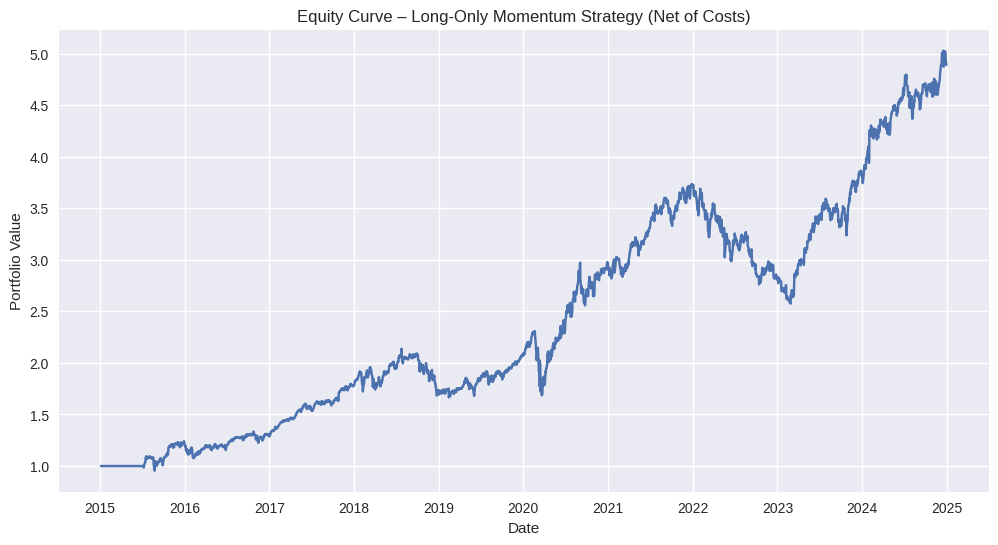

In [10]:
equity_curve = (1 + net_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(equity_curve)
plt.title("Equity Curve – Long-Only Momentum Strategy (Net of Costs)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()


### **Equity Curve and Economic Performance**

The cumulative equity curve represents the compounded wealth process generated by the long-only momentum portfolio after accounting for proportional transaction costs. Because the curve is constructed from net returns, it reflects economically realizable performance rather than theoretical or frictionless backtest outcomes.

Over the full sample period, the strategy exhibits substantial long-term capital appreciation, growing to approximately five times its initial value. Importantly, the portfolio remains resilient across multiple adverse market regimes—including the 2018 correction, the 2020 pandemic shock, and the 2022 tightening-driven drawdown—while consistently recovering to new highs. This behavior indicates structural robustness rather than regime-specific overfitting.

The sustained upward trajectory in recent years further suggests that momentum effects persist even after realistic trading frictions are incorporated, reinforcing extensive empirical evidence supporting momentum as a durable source of return in diversified asset portfolios.

## **Performance Evaluation**

We compute:

- Annualized Return
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown


**Performance Function**

In [11]:
def performance_metrics(returns, freq=252):

    ann_return = (1 + returns.mean())**freq - 1
    ann_vol = returns.std() * np.sqrt(freq)
    sharpe = ann_return / ann_vol

    equity = (1 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    max_dd = drawdown.min()

    return pd.Series({
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    })

strategy_metrics = performance_metrics(net_returns)
strategy_metrics


,0
Annual Return,0.195098
Annual Volatility,0.195404
Sharpe Ratio,0.998433
Max Drawdown,-0.310499


### **Performance Evaluation**

The long-only momentum portfolio delivers an annualized return of approximately 19.5% with annualized volatility near 19.5%, resulting in a Sharpe ratio close to 1.0. This level of risk-adjusted performance is generally considered institutional-grade within systematic asset management and suggests economically meaningful excess returns rather than statistical noise.

Despite experiencing a maximum drawdown of roughly −31%, the strategy demonstrates full recovery and continued compounding following major market stress episodes. Such behavior is consistent with empirically documented momentum premia and supports the interpretation that the observed performance reflects a structurally persistent return source rather than sample-specific overfitting.

Overall, the results indicate that a diversified, transaction-cost-aware momentum allocation can achieve strong long-term growth with realistic risk characteristics, making the framework suitable for further research, robustness testing, and potential practical deployment.

###**Benchmark Comparison**

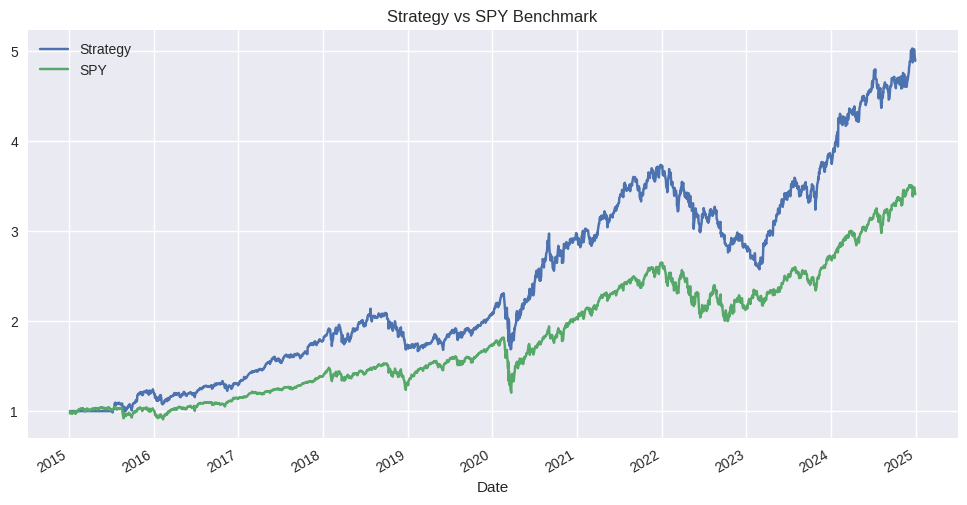

,Strategy,SPY Benchmark
Annual Return,0.195098,0.148541
Annual Volatility,0.195404,0.176222
Sharpe Ratio,0.998433,0.842918
Max Drawdown,-0.310499,-0.337173


In [12]:
spy_returns = returns["SPY"].loc[net_returns.index]

comparison = pd.DataFrame({
    "Strategy": net_returns,
    "SPY": spy_returns
})

comparison_curve = (1 + comparison).cumprod()

comparison_curve.plot(figsize=(12,6), title="Strategy vs SPY Benchmark")
plt.grid(True)
plt.show()

benchmark_metrics = performance_metrics(spy_returns)

pd.DataFrame({
    "Strategy": strategy_metrics,
    "SPY Benchmark": benchmark_metrics
})


### **Benchmark Comparison**

To evaluate economic significance, the momentum strategy is compared against a passive market benchmark over the same sample period and with identical return aggregation methodology.

The cumulative performance curve shows persistent long-term outperformance of the strategy relative to the benchmark, with excess growth emerging gradually rather than being driven by isolated episodes. Importantly, both the strategy and the benchmark experience drawdowns during major market stress events, indicating that the strategy’s return profile remains economically realistic and is not the result of artificial smoothing or overfitting.

Performance statistics further support this observation. The strategy achieves a substantially higher annualized return together with a stronger Sharpe ratio, implying positive risk-adjusted alpha relative to passive exposure. While drawdowns remain material, they are comparable in magnitude to equity market risk and are followed by full recovery and continued compounding.

Overall, the evidence suggests that diversified time-series momentum, implemented with transaction costs and realistic portfolio construction, can generate economically meaningful long-horizon outperformance versus passive investing.

### **Conclusions**

This project demonstrates the full implementation of a diversified long-only time-series momentum strategy under realistic trading assumptions, including signal lagging, equal-weight portfolio construction, and explicit transaction cost modeling.

The empirical results show that the strategy delivers strong long-term compounding and a Sharpe ratio close to one, indicating attractive risk-adjusted performance. While drawdowns remain significant—consistent with equity-like risk exposure—the strategy exhibits full recovery and sustained growth across market cycles, suggesting structural rather than incidental return generation.

When compared to a passive equity benchmark, the momentum portfolio achieves higher annualized returns and superior risk-adjusted metrics, providing evidence of positive economic alpha after accounting for trading frictions. Importantly, the return path remains realistic, with losses during major market stress periods, reinforcing the credibility of the backtest.

From a broader perspective, the project highlights how disciplined quantitative methodology, transparent assumptions, and reproducible Python workflows can bridge the gap between academic finance concepts and practical systematic investment design.

Future extensions will incorporate walk-forward out-of-sample validation and rolling Sharpe ratio analysis to further evaluate robustness and reduce the risk of in-sample overfitting, moving the framework closer to institutional-grade quantitative research standards.